# Dataset 2 - LMS-Based Statistical and Entropy Features using FP1 Reference

This notebook evaluates LMS-based preprocessing on Dataset 2 using FP1 as the reference channel and statistical EEG features for schizophrenia classification.

## Objectives

- unify and resample EEG signals from Dataset 2
- segment signals into overlapping windows
- apply LMS adaptive filtering using FP1 as reference
- extract energy, standard deviation, and Shannon entropy features
- evaluate Random Forest classification

In [ ]:
import os
import zipfile
import numpy as np
import mne
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

from PyEMD import EMD

from scipy.signal import resample as sciresample
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
subsets = ["subset_1.zip", "subset_2.zip", "subset_3.zip"]
base_dir = "/content"

for subset_zip in subsets:
    with zipfile.ZipFile(os.path.join(base_dir, subset_zip), 'r') as zip_ref:
        zip_ref.extractall(base_dir)
        print(f"Contenu extrait pour {subset_zip}")

Contenu extrait pour subset_1.zip
Contenu extrait pour subset_2.zip
Contenu extrait pour subset_3.zip


In [ ]:
def extract_category_from_gnr(gnr_path):
    try:
        with open(gnr_path, 'r') as f:
            for line in f:
                if line.startswith("category="):
                    cat_value = line.split("=")[1].strip()
                    if cat_value in ["Patient", "Control"]:
                        return cat_value
        return None
    except Exception as e:
        print(f"Erreur lecture {gnr_path}: {e}")
        return None

In [ ]:
def unify_channels(signal, desired_channels=24):

    n_channels, n_times = signal.shape
    if n_channels < desired_channels:
        new_signal = np.zeros((desired_channels, n_times), dtype=signal.dtype)
        new_signal[:n_channels, :] = signal
        return new_signal
    elif n_channels > desired_channels:
        print(f"Tronquage de {n_channels} canaux à {desired_channels} canaux.")
        return signal[:desired_channels, :]
    else:
        return signal

In [ ]:
def my_resample(signal, old_fs, target_fs=250):
    if abs(old_fs - target_fs) < 1e-9:
        return signal, old_fs

    n_channels, n_times_old = signal.shape
    n_times_new = int(n_times_old * (target_fs / old_fs))

    resampled = np.zeros((n_channels, n_times_new), dtype=signal.dtype)
    for ch in range(n_channels):
        resampled[ch, :] = sciresample(signal[ch, :], n_times_new)

    return resampled, target_fs

In [ ]:
def segment_signal(signal, fs, window_size=10, overlap=0.5):

    window_samples = int(window_size * fs)
    step = int(window_samples * (1 - overlap))
    segments = []
    for start in range(0, signal.shape[1] - window_samples + 1, step):
        seg = signal[:, start:start+window_samples]
        segments.append(seg)
    return segments

In [ ]:
def emd_channel(channel_data, max_imf=5):

    emd = EMD()
    imfs = emd(channel_data)
    if imfs.shape[0] > max_imf:
        imfs = imfs[:max_imf, :]
    return imfs

In [ ]:
def compute_energy_1d(signal_1d):
    return np.sum(signal_1d**2)

def compute_std_1d(signal_1d):
    return np.std(signal_1d)

def compute_shannon_entropy_1d(signal_1d, eps=1e-10):
    abs_sig = np.abs(signal_1d)
    sum_sig = np.sum(abs_sig) + eps
    probs = abs_sig / sum_sig
    return - np.sum(probs * np.log(probs + eps))

In [ ]:
def emd_extract_features_segment(segment, max_imf=5):

    n_channels, n_times = segment.shape
    feats = []

    for ch in range(n_channels):
        imfs = emd_channel(segment[ch, :], max_imf=max_imf)
        n_imf_ch, n_times_ch = imfs.shape


        padded_imfs = np.zeros((max_imf, n_times_ch))
        padded_imfs[:n_imf_ch, :] = imfs

        for i_imf in range(max_imf):
            imf_1d = padded_imfs[i_imf, :]
            e = compute_energy_1d(imf_1d)
            s = compute_std_1d(imf_1d)
            h = compute_shannon_entropy_1d(imf_1d)
            feats.extend([e, s, h])

    return np.array(feats)

In [ ]:
def build_dataset(base_dir,
                  subsets=["subset_1","subset_2","subset_3"],
                  desired_channels=24,
                  target_fs=250,
                  window_size=10,
                  overlap=0.5,
                  max_imf=5):
    X = []
    y = []

    subfolders = ["1","2","3"]

    for subset_name in subsets:
        subset_folder = os.path.join(base_dir, subset_name)
        if not os.path.isdir(subset_folder):
            print(f"{subset_folder} n'existe pas. Ignoré.")
            continue

        for subject in os.listdir(subset_folder):
            subject_dir = os.path.join(subset_folder, subject)
            if not os.path.isdir(subject_dir):
                continue


            category = None
            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                gnr_file = None
                for f in os.listdir(sf_path):
                    if f.lower().endswith(".gnr"):
                        gnr_file = os.path.join(sf_path, f)
                        break
                if gnr_file:
                    cat = extract_category_from_gnr(gnr_file)
                    if cat in ["Patient","Control"]:
                        category = cat
                        break

            if category is None:
                continue
            label = 1 if category == "Patient" else 0

            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                for f in os.listdir(sf_path):
                    if f.lower().endswith(".edf"):
                        edf_path = os.path.join(sf_path, f)
                        try:
                            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
                            old_fs = raw.info['sfreq']
                            signal = raw.get_data()

                            # Unify channels : 24
                            signal_24 = unify_channels(signal, desired_channels)

                            # Resample : 256 Hz
                            signal_rs, fs_rs = my_resample(signal_24, old_fs, target_fs)


                            segments = segment_signal(signal_rs, fs_rs,
                                                      window_size=window_size,
                                                      overlap=overlap)

                            # EMD + (énergie, éc-type, entropie)
                            for seg in segments:
                                feat = emd_extract_features_segment(seg, max_imf=max_imf)
                                X.append(feat)
                                y.append(label)

                        except Exception as e:
                            print(f"Erreur lecture {edf_path}: {e}")

    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
X, y = build_dataset(
    base_dir="/content",
    subsets=["subset_1","subset_2","subset_3"],
    desired_channels=24,
    target_fs=256,
    window_size=10,
    overlap=0.5,
    max_imf=5
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3805, 360)
y shape: (3805,)


**LMS**

In [ ]:
def compute_energy_1d(signal_1d):
    return np.sum(signal_1d**2)

In [ ]:
def select_high_energy_imfs(imfs, energy_threshold=1e2):

    selected = []
    for i in range(imfs.shape[0]):
        e = compute_energy_1d(imfs[i, :])
        if e >= energy_threshold:
            selected.append(imfs[i, :])
    if len(selected) == 0:
        return []
    return np.stack(selected, axis=0) 


In [ ]:
def compute_std_1d(signal_1d):
    return np.std(signal_1d)

def compute_shannon_entropy_1d(signal_1d, eps=1e-10):
    abs_sig = np.abs(signal_1d)
    sum_sig = np.sum(abs_sig) + eps
    probs = abs_sig / sum_sig
    return -np.sum(probs * np.log(probs + eps))


In [ ]:
def extract_features_from_imfs(imfs_filtered):
  
    feats = []
    for i in range(imfs_filtered.shape[0]):
        imf_1d = imfs_filtered[i, :]
        e = compute_energy_1d(imf_1d)
        s = compute_std_1d(imf_1d)
        h = compute_shannon_entropy_1d(imf_1d)
        feats.extend([e, s, h])
    return np.array(feats)


In [ ]:
def emd_channel(channel_data, max_imf=7):

    emd = EMD()
    imfs = emd(channel_data)  
    n_imf_ch, n_times = imfs.shape

    if n_imf_ch >= max_imf:
        return imfs[:max_imf, :]
    else:
        # Zero-pad si moins de max_imf
        new_imfs = np.zeros((max_imf, n_times))
        new_imfs[:n_imf_ch, :] = imfs
        return new_imfs


In [ ]:
def lms_filter(imf, reference, mu=0.01):
    n_times = len(imf)
    output = np.zeros(n_times)
    w = 0.0
    for i in range(n_times):
        e = imf[i] - w * reference[i]
        w = w + 2*mu* e * reference[i]
        output[i] = imf[i] - e 
    return output


In [ ]:
def apply_lms_on_imfs(imfs, reference=None, mu=0.01):
    max_imf, n_times = imfs.shape
    if reference is None:
        reference = np.zeros(n_times)

    filtered = np.zeros((max_imf, n_times))
    for i in range(max_imf):
        filtered[i, :] = lms_filter(imfs[i, :], reference, mu=mu)
    return filtered


In [ ]:
def compute_energy_1d(signal_1d):
    return np.sum(signal_1d**2)

def compute_std_1d(signal_1d):
    return np.std(signal_1d)

def compute_shannon_entropy_1d(signal_1d, eps=1e-10):
    abs_sig = np.abs(signal_1d)
    sum_sig = np.sum(abs_sig) + eps
    probs = abs_sig / sum_sig
    return -np.sum(probs * np.log(probs + eps))

def extract_features_from_imfs(imfs_filtered):

    max_imf, n_times = imfs_filtered.shape
    feats = []
    for i in range(max_imf):
        e = compute_energy_1d(imfs_filtered[i,:])
        s = compute_std_1d(imfs_filtered[i,:])
        h = compute_shannon_entropy_1d(imfs_filtered[i,:])
        feats.extend([e,s,h])
    return np.array(feats)  # dimension 3*max_imf


In [ ]:
def lms_filter_with_reference(signal, ref, mu=0.005, filter_len=10):

    signal = np.asarray(signal)
    ref = np.asarray(ref)
    n_samples = len(signal)

    y = np.zeros(n_samples)
    w = np.zeros(filter_len)

    for n in range(filter_len, n_samples):
        x_vec = ref[n-filter_len:n]  # shape (filter_len,)
        y[n] = np.dot(w, x_vec)
        error = signal[n] - y[n]
        w += 2 * mu * error * x_vec

    return y


def lms_filter_with_reference_FP1_multichannel(data,
                                               fp1_index=0,
                                               mu=0.005,
                                               filter_len=10):

    data = np.asarray(data)
    n_channels, n_samples = data.shape

    ref = data[fp1_index, :]  # canal FP1
    filtered_data = np.zeros_like(data)

    for ch in range(n_channels):
        if ch == fp1_index:
            # On ne filtre pas FP1 => on le laisse intact
            filtered_data[ch, :] = data[ch, :]
        else:
            filtered_data[ch, :] = lms_filter_with_reference(
                signal=data[ch, :],
                ref=ref,
                mu=mu,
                filter_len=filter_len
            )
    return filtered_data

In [ ]:
def extract_features_from_segment(segment):
    n_channels, n_samples = segment.shape
    feats = []
    for ch in range(n_channels):
        e = compute_energy_1d(segment[ch,:])
        s = compute_std_1d(segment[ch,:])
        h = compute_shannon_entropy_1d(segment[ch,:])
        feats.extend([e,s,h])
    return np.array(feats)

In [ ]:
def build_dataset_lms_fp1(base_dir,
                          subsets=["subset_1","subset_2","subset_3"],
                          fp1_index=0,   # index du canal FP1
                          desired_channels=24,
                          target_fs=250,
                          window_size=10,
                          overlap=0.5,
                          mu=0.005,
                          filter_len=10):

    X = []
    y = []

    subfolders = ["1","2","3"]

    for subset_name in subsets:
        subset_folder = os.path.join(base_dir, subset_name)
        if not os.path.isdir(subset_folder):
            print(f"{subset_folder} n'existe pas ou n'est pas un dossier. Ignoré.")
            continue

        for subject in os.listdir(subset_folder):
            subject_dir = os.path.join(subset_folder, subject)
            if not os.path.isdir(subject_dir):
                continue

            category = None
            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                gnr_file = None
                for f in os.listdir(sf_path):
                    if f.lower().endswith(".gnr"):
                        gnr_file = os.path.join(sf_path, f)
                        break
                if gnr_file:
                    cat = extract_category_from_gnr(gnr_file)
                    if cat in ["Patient","Control"]:
                        category = cat
                        break

            if category is None:
                continue
            label = 1 if category=="Patient" else 0

            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue

                for f in os.listdir(sf_path):
                    if f.lower().endswith(".edf"):
                        edf_path = os.path.join(sf_path, f)
                        try:
                            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

                            data = raw.get_data()
                            old_fs = raw.info['sfreq']

                            if desired_channels:
                                data = unify_channels(data, desired_channels)

                            data_rs, fs_rs = my_resample(data, old_fs, target_fs)

                            segments = segment_signal(data_rs, fs_rs,
                                                      window_size=window_size,
                                                      overlap=overlap)

                            for seg in segments:
                                seg_filtered = lms_filter_with_reference_FP1_multichannel(
                                    seg,
                                    fp1_index=fp1_index,
                                    mu=mu,
                                    filter_len=filter_len
                                )
                                feats = extract_features_from_segment(seg_filtered)
                                X.append(feats)
                                y.append(label)

                        except Exception as e:
                            print(f"Erreur lecture {edf_path}: {e}")

    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
base_dir = "/content"
subsets = ["subset_1","subset_2","subset_3"]

fp1_index = 0
desired_channels = 24
target_fs = 256
window_size = 10
overlap = 0.5
mu = 0.005
filter_len = 10

X, y = build_dataset_lms_fp1(
    base_dir=base_dir,
    subsets=subsets,
    fp1_index=fp1_index,
    desired_channels=desired_channels,
    target_fs=target_fs,
    window_size=window_size,
    overlap=overlap,
    mu=mu,
    filter_len=filter_len
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3805, 72)
y shape: (3805,)


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       374
           1       0.86      0.95      0.91       387

    accuracy                           0.90       761
   macro avg       0.90      0.90      0.90       761
weighted avg       0.90      0.90      0.90       761



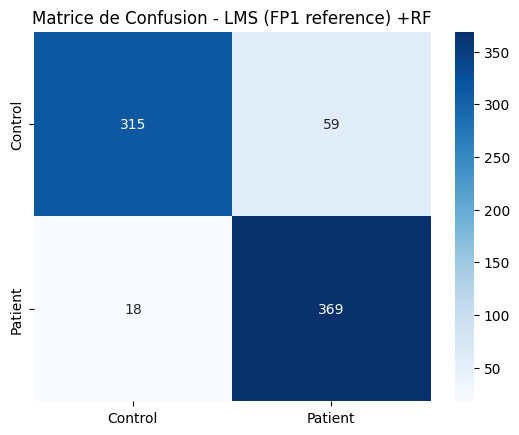

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control","Patient"], yticklabels=["Control","Patient"])
plt.title("Matrice de Confusion - LMS (FP1 reference) +RF")
plt.show()

In [ ]:
# KFold Cross Validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='accuracy')
print(f"Random Forest - KFold CV scores: {rf_scores}")
print(f"Random Forest - Mean CV accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Random Forest - KFold CV scores: [0.89093298 0.90275953 0.89224704 0.8869908  0.89750329]
Random Forest - Mean CV accuracy: 0.894 ± 0.005
